# Extrusion force data cleaning

In this notebook, we develop a pipeline for extrusion force data cleaning. We aim to integrate this pipeline to the HEPiC software, so that people can easily remove useless data, separate data into temperature / velocity groups and make standard visuals, such as force curves and phase diagrams.

## 0 Pacakges

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams["xtick.direction"] = "in"
matplotlib.rcParams["ytick.direction"] = "in"
plt.rcParams['xtick.major.size'] = 2  # Length of major ticks
plt.rcParams['ytick.major.size'] = 2  # Length of major ticks
plt.rcParams['xtick.minor.size'] = 1  # Length of minor ticks
plt.rcParams['ytick.minor.size'] = 1  # Length of minor ticks

## 1 Load data

In [3]:
raw_data = pd.read_csv("force_raw_data.csv")

In [107]:
cleaned_steps, data_clean = clean_data(raw_data)

inferred step length: 275
number of steps: 100


In [13]:
raw_data.head()

,time_s,temperature_C,feedrate_mms,extrusion_force_N,die_diameter_px,die_temperature_C,measured_temperature_C,measured_feedrate_mms,meter_count_mm
0,1447.6,190.0,0.0,0.70854,31.334375,154.1,190.30,0.0,526.428513
1,1447.7,190.0,0.0,0.70854,32.467163,154.5,190.30,0.0,526.428513
2,1447.8,190.0,0.0,0.70854,27.451502,154.5,190.28,0.0,526.428513
3,1447.9,190.0,0.0,0.70854,29.067417,154.5,190.28,0.0,526.428513
4,1448.0,190.0,0.0,0.70854,32.783390,154.4,190.28,0.0,526.428513


Text(0, 0.5, 'Extrusion Force, $F$ (N)')

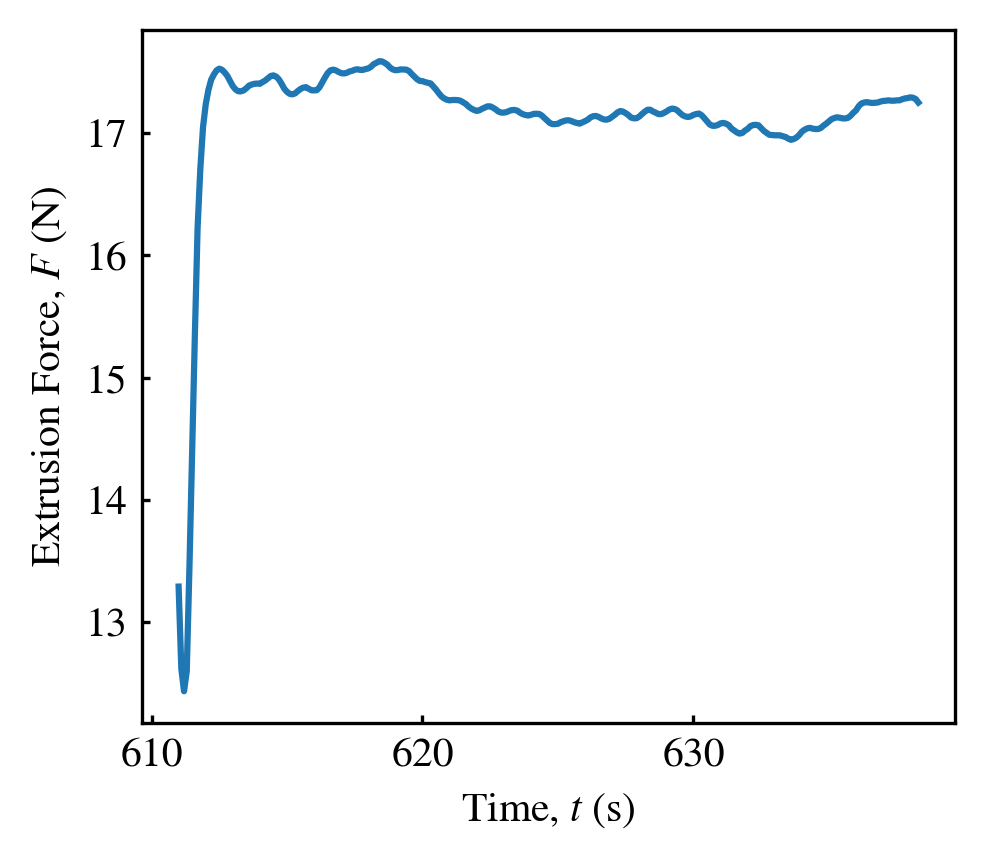

In [77]:
step = cleaned_steps[21]
plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(step["time_s"], step["extrusion_force_N"])
# plt.plot(step["time_s"], step["feedrate_mms"])
plt.xlabel("Time, $t$ (s)")
plt.ylabel("Extrusion Force, $F$ (N)")

In [88]:
stats = extrusion_statistics(cleaned_steps, clip=10)

In [70]:
var = stats["extrusion_force_N_std"] / stats["extrusion_force_N_mean"]

Text(0, 0.5, 'Relative std of extrusion force')

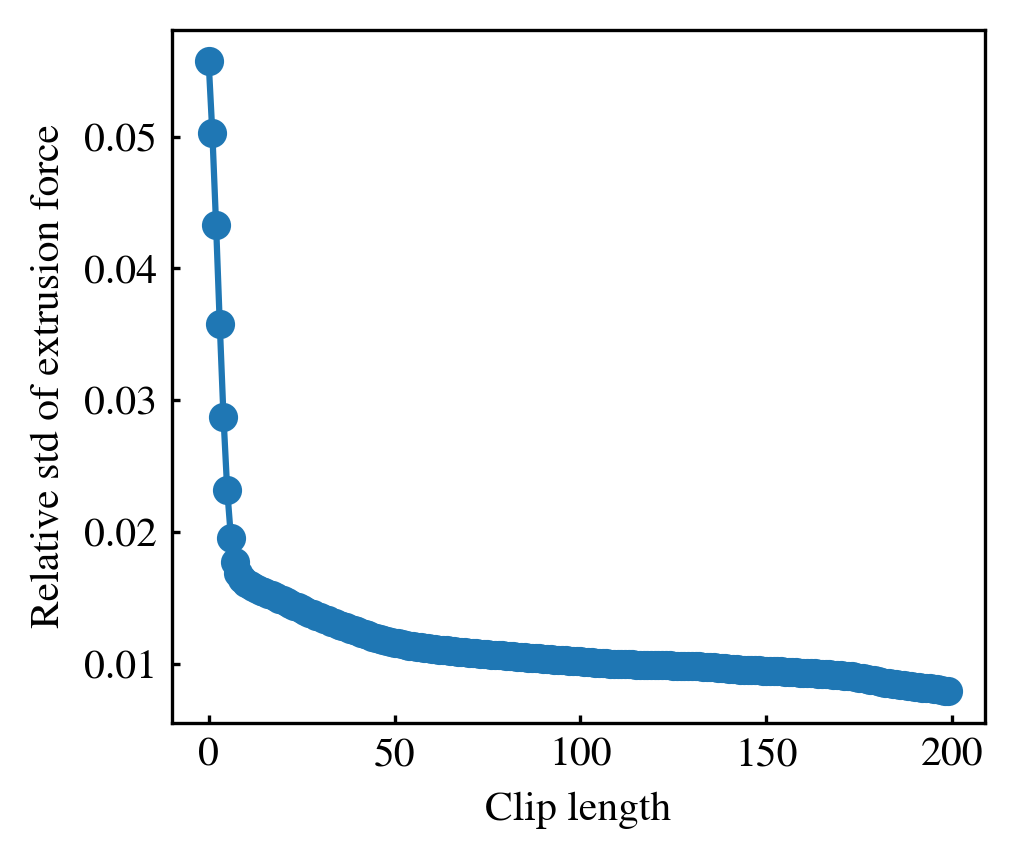

In [87]:
var_list = []
clip_range = range(0, 200)
for clip in clip_range:
    stats = extrusion_statistics(cleaned_steps, clip=clip)
    var = stats["extrusion_force_N_std"] / stats["extrusion_force_N_mean"]
    var_list.append(var.mean())
plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(clip_range, var_list, marker="o")
plt.xlabel("Clip length")
plt.ylabel("Relative std of extrusion force")

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\zhengyang\AppData\Local\Temp\ipykernel_8036\2430584826.py:3: SyntaxWarning: invalid escape sequence '\c'
  plt.errorbar(gT["feedrate_mms"], gT["extrusion_force_N_mean"], yerr=gT["extrusion_force_N_std"], marker="o", markersize=5, capsize=2, capthick=1, lw=1, ls="", label=f"{T:.1f}$^\circ$C")


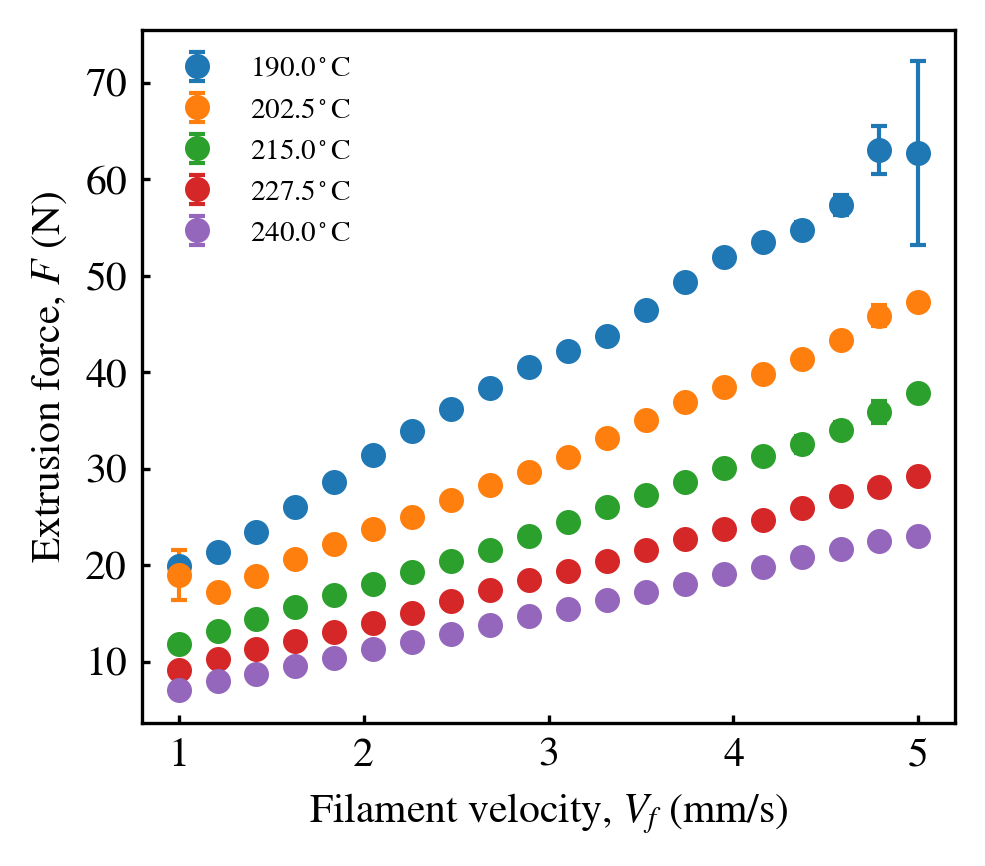

In [102]:
plt.figure(figsize=(3.5, 3), dpi=300)
for T, gT in stats.groupby("temperature_C"):
    plt.errorbar(gT["feedrate_mms"], gT["extrusion_force_N_mean"], yerr=gT["extrusion_force_N_std"], marker="o", markersize=5, capsize=2, capthick=1, lw=1, ls="", label=f"{T:.1f}$^\circ$C")
plt.xlabel("Filament velocity, $V_f$ (mm/s)")
plt.ylabel("Extrusion force, $F$ (N)")
plt.legend(fontsize=7, frameon=False)

In [ ]:
def extrusion_statistics(steps: list[pd.DataFrame], 
                         clip: int = 0):
    """
    Compute statistics for each extrusion step after clipping the initial data points.
    The statistics include mean feedrate, mean temperature, mean extrusion force, and standard deviation of extrusion force.

    Parameters
    ----------
    steps : list[pd.DataFrame]
        A list of DataFrames, each representing an extrusion step with columns "feedrate_mms", "temperature_C", and "extrusion_force_N".
    clip : int, optional
        The number of initial data points to clip from each step before computing statistics, by default 0.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame containing the computed statistics for each step, with columns "feedrate_mms", "temperature_C", "extrusion_force_N_mean", and "extrusion_force_N_std".
    
    Example
    -------
    >>> stats = extrusion_statistics(cleaned_steps, clip=10)
    """
    stats = []
    for step in steps:
        clipped = step[clip:]
        stat = {
            "feedrate_mms": clipped["feedrate_mms"].mean(),
            "temperature_C": clipped["temperature_C"].mean(),
            "extrusion_force_N_mean": clipped["extrusion_force_N"].mean(),
            "extrusion_force_N_std": clipped["extrusion_force_N"].std()
        }
        stats.append(stat)
    return pd.DataFrame(stats)

In [106]:
def clean_data(raw_data: pd.DataFrame,
               feedrate_col: str = "feedrate_mms"):
    """
    Parameters
    ----------
    raw_data : pd.DataFrame
        the original table generated by HEPiC
    feedrate_col : str
        the name of the feedrate column in the data table. This is used to identify the parameter steps.

    Returns
    -------
    cleaned_steps : list
        a list of pd.DataFrame, each of which is regarded as a single parameter set. 
    data_clean : pd.DataFrame
        the cleaned data table.

    Examples
    --------
    >>> cleaned_steps, data_clean = clean_data(data)
    """

    # define tiny
    eps = np.finfo(float).eps

    # remove tiny force entries
    data_clean = raw_data.loc[(raw_data.extrusion_force_N >= eps)&(raw_data[feedrate_col]>eps)].copy()

    # time start at 0
    data_clean.loc[:, "time_s"] -= data_clean.time_s.min()
    # min_length = step_length // 2
    
    ####
    data_clean.loc[:, "gradient"] = data_clean[feedrate_col].diff().abs()
    data_clean.loc[:, "is_flat"] = data_clean["gradient"].lt(eps)
    data_clean.loc[:, "step_id"] = (~data_clean["is_flat"]).cumsum()

    # infer the step length
    step_length = 0
    for step, g_step in data_clean.groupby("step_id"):
        step_length = max(step_length, len(g_step))
    
    print(f"inferred step length: {step_length}")

    min_length = step_length // 2

    # filter out short steps
    cleaned_steps = []
    for step, g_step in data_clean.groupby("step_id"):
        if len(g_step) > min_length:
            cleaned_steps.append(g_step)
    
    print(f"number of steps: {len(cleaned_steps)}")

    return cleaned_steps, data_clean

In [30]:
np.finfo

numpy.finfo